# OLCI vs PACE BRT on the same profiles

Join the CHLA-Z methods table to `olci_l3_matchups.parquet` on `profile_id`. Keep rows where **all 11 OLCI bands** are finite (PACE Rrs is already complete on these ids).

Then fit the same BRT as `notebooks/methods_fit_BRT_CHLA_z.ipynb` (`HistGradientBoostingRegressor`, `log10(CHLA)`, `solar_hour` + `type`, `random_state=42`) twice on the **same train/test ids**:

1. **PACE-full** — ~172 `pace_Rrs_*` bands  
2. **OLCI-11** — the 11 `olci_Rrs_*` bands  
3. **PACE-11** — nearest PACE band to each OLCI center (control: same wavelengths, same sensor)

Kernel: `gobgc`. Does not import `ml_utils`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

OLCI_BANDS = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]
OLCI_COLS = [f"olci_Rrs_{nm}" for nm in OLCI_BANDS]
PACE_11 = {
    400: "pace_Rrs_400",
    412: "pace_Rrs_413",
    443: "pace_Rrs_442",
    490: "pace_Rrs_490",
    510: "pace_Rrs_510",
    560: "pace_Rrs_560",
    620: "pace_Rrs_620",
    665: "pace_Rrs_665",
    674: "pace_Rrs_673",
    681: "pace_Rrs_681",
    709: "pace_Rrs_709",
}
PACE_11_COLS = [PACE_11[nm] for nm in OLCI_BANDS]
EXTRA = ["solar_hour", "type"]
BRT_KW = dict(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    validation_fraction=0.1,
    early_stopping=True,
    random_state=42,
)

DATA = Path("/Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data")
HERE = Path("/Users/nmamnun/GO-BGC-Workshop/2026-go-bgc-hackweek/contributor_folders/nama")
if not (DATA / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        cand = p.parent / "chla-z" / "brt_training_data"
        if (cand / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
            DATA = cand
        if (p / "contributor_folders" / "nama").is_dir():
            HERE = p / "contributor_folders" / "nama"

OLCI_FILE = HERE / "olci_l3_matchups.parquet"
print("DATA:", DATA)
print("OLCI:", OLCI_FILE, "exists", OLCI_FILE.is_file())

DATA: /Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data
OLCI: /Users/nmamnun/GO-BGC-Workshop/2026-go-bgc-hackweek/contributor_folders/nama/olci_l3_matchups.parquet exists True


## 1. Methods table (Argo + OOI, solar hour, biofouling)

Same merge as the methods notebook. Solar hour is inlined so we do not import `ml_utils`. Drop duplicate OOI `profile_id`s so the join is one row per id.

In [2]:
def add_solar_hour(df, time="time", lon="lon"):
    out = df.copy()
    t = pd.to_datetime(out[time], utc=True)
    utc_hour = t.dt.hour + t.dt.minute / 60.0 + t.dt.second / 3600.0
    lon_e = out[lon].astype(float)
    if np.nanmax(lon_e.to_numpy()) > 180:
        lon_e = ((lon_e + 180) % 360) - 180
    out["solar_hour"] = (utc_hour.to_numpy() + lon_e.to_numpy() / 15.0) % 24.0
    return out


def parse_depth_bin(col):
    _, a, b = col.split("_")
    return int(a), int(b)


def flag_deep_biofouling(df, deep_bins, min_valid=5, min_chl=1.0, max_spread=2):
    bad = []
    for pid, sub in df.groupby("profile_id"):
        vals = sub[deep_bins].to_numpy(dtype=float).ravel()
        vals = vals[np.isfinite(vals)]
        if vals.size < min_valid:
            continue
        if (vals.min() > min_chl) and ((vals.max() - vals.min()) < max_spread):
            bad.append(pid)
    return bad

argo = pd.read_parquet(DATA / "CHLA_argo_profiles_plus_PACE.parquet")
argo = argo.rename(columns={"LATITUDE": "lat", "LONGITUDE": "lon", "TIME": "time"})
rrs_cols = [c for c in argo.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
chl_cols = [c for c in argo.columns if c.startswith("CHLA_") and c[-1].isdigit()]
keep = ["profile_id", "time", "lat", "lon"] + rrs_cols + chl_cols + ["pace_chlor_a", "pace_Kd_490"]
argo = argo[keep].copy()
argo["type"] = 0

ooi = pd.read_parquet(DATA / "CHLA_ooi_profiles_plus_PACE.parquet")
ooi = ooi[keep].copy()
ooi["type"] = 1

dataset = pd.concat([argo, ooi], ignore_index=True)
dataset = add_solar_hour(dataset)
dataset = dataset.dropna(subset=rrs_cols, how="all").reset_index(drop=True)
print("after merge + PACE Rrs dropna:", dataset.shape)

chl_cols = sorted(
    [c for c in dataset.columns if c.startswith("CHLA_") and c[-1].isdigit()],
    key=lambda c: parse_depth_bin(c)[0],
)
deep_bins = [c for c in chl_cols if 100 <= 0.5 * sum(parse_depth_bin(c)) <= 200]
bad_ids = flag_deep_biofouling(dataset, deep_bins)
print(f"flagged {len(bad_ids)} biofouled profile_id")
dataset = dataset[~dataset["profile_id"].isin(bad_ids)].reset_index(drop=True)
n0 = len(dataset)
dataset = dataset.drop_duplicates("profile_id").reset_index(drop=True)
print(f"unique profile_id: {n0} -> {len(dataset)}")

after merge + PACE Rrs dropna: (5540, 200)
flagged 20 biofouled profile_id
unique profile_id: 5510 -> 4712


## 2. Inner join OLCI and keep complete spectra

In [3]:
olci = pd.read_parquet(OLCI_FILE)
olci_keep = ["profile_id", "olci_sat"] + OLCI_COLS
dataset = dataset.merge(olci[olci_keep], on="profile_id", how="inner")
print("inner join on profile_id:", len(dataset))

ok = dataset[OLCI_COLS].notna().all(axis=1)
print(f"all 11 OLCI finite: {int(ok.sum())}/{len(dataset)}")
dataset = dataset.loc[ok].reset_index(drop=True)
print("comparison table:", dataset.shape)
print(dataset["type"].map({0: "argo", 1: "ooi"}).value_counts())
print("olci_sat:")
print(dataset["olci_sat"].value_counts())

inner join on profile_id: 4712
all 11 OLCI finite: 2369/4712
comparison table: (2369, 212)
type
argo    1467
ooi      902
Name: count, dtype: int64
olci_sat:
olci_sat
S3A    1363
S3B    1006
Name: count, dtype: int64


## 3. Shared train/test split

Split **after** the OLCI filter, by `profile_id`, `random_state=42`. Both models see the same ids. Per-depth fits still drop rows with NaN CHLA in that bin.

In [4]:
ids = dataset["profile_id"].to_numpy()
train_ids, test_ids = train_test_split(ids, test_size=0.2, random_state=42)
train_idx = dataset.index[dataset["profile_id"].isin(train_ids)].to_numpy()
test_idx = dataset.index[dataset["profile_id"].isin(test_ids)].to_numpy()
print(f"train {len(train_idx)}  test {len(test_idx)}")

PACE_COLS = [c for c in dataset.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
MODELS = {
    "PACE-full": PACE_COLS,
    "PACE-11": PACE_11_COLS,
    "OLCI-11": OLCI_COLS,
}
print({k: len(v) for k, v in MODELS.items()})

train 1895  test 474
{'PACE-full': 172, 'PACE-11': 11, 'OLCI-11': 11}


## 4. Surface BRT (`CHLA_0_10`)

In [5]:
def xy_for_bin(df, y_col, rrs):
    tab = df[[y_col] + rrs + EXTRA].copy()
    tab = tab.rename(columns={y_col: "y"})
    tab = tab.where(tab["y"] > 0)
    tab["y"] = np.log10(tab["y"])
    tab = tab.dropna(subset=["y"])
    return tab[rrs + EXTRA], tab["y"]


def fit_one(name, rrs, y_col="CHLA_0_10"):
    Xtr, ytr = xy_for_bin(dataset.loc[train_idx], y_col, rrs)
    Xte, yte = xy_for_bin(dataset.loc[test_idx], y_col, rrs)
    model = HistGradientBoostingRegressor(**BRT_KW).fit(Xtr, ytr)
    pred = model.predict(Xte)
    r2 = r2_score(yte, pred)
    rmse = float(np.sqrt(mean_squared_error(yte, pred)))
    print(f"{name:10s}  n_train={len(Xtr):4d}  n_test={len(Xte):4d}  R2={r2:.3f}  RMSE={rmse:.3f}  (log10 CHLA)")
    return model, r2, rmse

surface = {}
for name, rrs in MODELS.items():
    surface[name] = fit_one(name, rrs)

PACE-full   n_train=1224  n_test= 322  R2=0.762  RMSE=0.354  (log10 CHLA)
PACE-11     n_train=1224  n_test= 322  R2=0.769  RMSE=0.348  (log10 CHLA)
OLCI-11     n_train=1224  n_test= 322  R2=0.774  RMSE=0.344  (log10 CHLA)


## 5. One BRT per depth bin

Same `train_idx` / `test_idx` for every depth. Metrics are on `log10(CHLA)`.

In [6]:
def metrics_vs_depth(name, rrs):
    rows = []
    models = {}
    for col in chl_cols:
        a, b = parse_depth_bin(col)
        z = 0.5 * (a + b)
        Xtr, ytr = xy_for_bin(dataset.loc[train_idx], col, rrs)
        Xte, yte = xy_for_bin(dataset.loc[test_idx], col, rrs)
        if len(Xtr) < 20 or len(Xte) < 10:
            rows.append({"model": name, "bin": col, "z": z, "n_test": len(Xte),
                         "r2": np.nan, "rmse": np.nan})
            continue
        model = HistGradientBoostingRegressor(**BRT_KW).fit(Xtr, ytr)
        models[col] = model
        pred = model.predict(Xte)
        rows.append({
            "model": name, "bin": col, "z": z, "n_test": len(Xte),
            "r2": r2_score(yte, pred),
            "rmse": float(np.sqrt(mean_squared_error(yte, pred))),
        })
        print(f"{name:10s} {col:14s}  n_test={len(Xte):4d}  R2={rows[-1]['r2']:.3f}  RMSE={rows[-1]['rmse']:.3f}")
    return pd.DataFrame(rows), models

parts = []
fitted = {}
for name, rrs in MODELS.items():
    print("===", name, "===")
    tab, models = metrics_vs_depth(name, rrs)
    parts.append(tab)
    fitted[name] = models
metrics = pd.concat(parts, ignore_index=True)
metrics

=== PACE-full ===
PACE-full  CHLA_0_10       n_test= 322  R2=0.762  RMSE=0.354
PACE-full  CHLA_10_20      n_test= 206  R2=0.841  RMSE=0.288
PACE-full  CHLA_20_30      n_test= 251  R2=0.831  RMSE=0.280
PACE-full  CHLA_30_40      n_test= 268  R2=0.794  RMSE=0.297
PACE-full  CHLA_40_50      n_test= 262  R2=0.755  RMSE=0.269
PACE-full  CHLA_50_60      n_test= 254  R2=0.590  RMSE=0.311
PACE-full  CHLA_60_70      n_test= 256  R2=0.469  RMSE=0.342
PACE-full  CHLA_70_80      n_test= 261  R2=0.378  RMSE=0.341
PACE-full  CHLA_80_90      n_test= 212  R2=0.296  RMSE=0.352
PACE-full  CHLA_90_100     n_test= 211  R2=0.285  RMSE=0.354
PACE-full  CHLA_100_110    n_test= 200  R2=0.325  RMSE=0.379
PACE-full  CHLA_110_120    n_test= 203  R2=0.352  RMSE=0.364
PACE-full  CHLA_120_130    n_test= 215  R2=0.406  RMSE=0.363
PACE-full  CHLA_130_140    n_test= 208  R2=0.288  RMSE=0.418
PACE-full  CHLA_140_150    n_test= 216  R2=0.301  RMSE=0.421
PACE-full  CHLA_150_160    n_test= 209  R2=0.213  RMSE=0.452
PACE-f

,model,bin,z,n_test,r2,rmse
0,PACE-full,CHLA_0_10,5.0,322,0.761557,0.353506
1,PACE-full,CHLA_10_20,15.0,206,0.841481,0.288038
2,PACE-full,CHLA_20_30,25.0,251,0.831379,0.280463
3,PACE-full,CHLA_30_40,35.0,268,0.794301,0.296757
4,PACE-full,CHLA_40_50,45.0,262,0.754934,0.268698
5,PACE-full,CHLA_50_60,55.0,254,0.590012,0.310669
6,PACE-full,CHLA_60_70,65.0,256,0.468731,0.342006
7,PACE-full,CHLA_70_80,75.0,261,0.378265,0.341167
8,PACE-full,CHLA_80_90,85.0,212,0.296482,0.351786
9,PACE-full,CHLA_90_100,95.0,211,0.284957,0.353927


## 6. RMSE and R² vs depth

rmse                            r2                      n_test  \
model   OLCI-11   PACE-11 PACE-full   OLCI-11   PACE-11 PACE-full OLCI-11   
z                                                                           
5.0    0.344220  0.347857  0.353506  0.773919  0.769117  0.761557   322.0   
15.0   0.317799  0.303359  0.288038  0.807031  0.824169  0.841481   206.0   
25.0   0.267472  0.284718  0.280463  0.846637  0.826223  0.831379   251.0   
35.0   0.294614  0.293895  0.296757  0.797261  0.798250  0.794301   268.0   
45.0   0.262441  0.271240  0.268698  0.766216  0.750276  0.754934   262.0   
55.0   0.300407  0.296733  0.310669  0.616649  0.625968  0.590012   254.0   
65.0   0.335997  0.352586  0.342006  0.487234  0.435351  0.468731   256.0   
75.0   0.350340  0.339007  0.341167  0.344385  0.386115  0.378265   261.0   
85.0   0.365225  0.352726  0.351786  0.241703  0.292717  0.296482   212.0   
95.0   0.341079  0.356639  0.353927  0.335929  0.273955  0.284957   211.0   
105.0  0.361217  0.382476  0.378785  0.386267  0.311899  0.325117   200.0   
115.0  0.351151  0.369644  0.364289  0.398297  0.333254  0.352430   203.0   
125.0  0.343678  0.347939  0.362550  0.465864  0.452538  0.405594   215.0   
135.0  0.400388  0.409386  0.418384  0.348205  0.318580  0.288297   208.0   
145.0  0.405229  0.409643  0.420629  0.351205  0.336993  0.300954   216.0   
155.0  0.465640  0.436129  0.452277  0.165326  0.267771  0.212544   209.0   
165.0  0.448106  0.439165  0.433333  0.192273  0.224183  0.244654   224.0   
175.0  0.473192  0.430256  0.432554  0.090959  0.248442  0.240390   216.0   
185.0  0.447321  0.422887  0.414161  0.167615  0.256067  0.286449   203.0   
195.0  0.434726  0.399973  0.400546  0.130554  0.264010  0.261898   202.0   

                         
model PACE-11 PACE-full  
z                        
5.0     322.0     322.0  
15.0    206.0     206.0  
25.0    251.0     251.0  
35.0    268.0     268.0  
45.0    262.0     262.0  
55.0    254.0     254.0  
65.0    256.0     256.0  
75.0    261.0     261.0  
85.0    212.0     212.0  
95.0    211.0     211.0  
105.0   200.0     200.0  
115.0   203.0     203.0  
125.0   215.0     215.0  
135.0   208.0     208.0  
145.0   216.0     216.0  
155.0   209.0     209.0  
165.0   224.0     224.0  
175.0   216.0     216.0  
185.0   203.0     203.0  
195.0   202.0     202.0

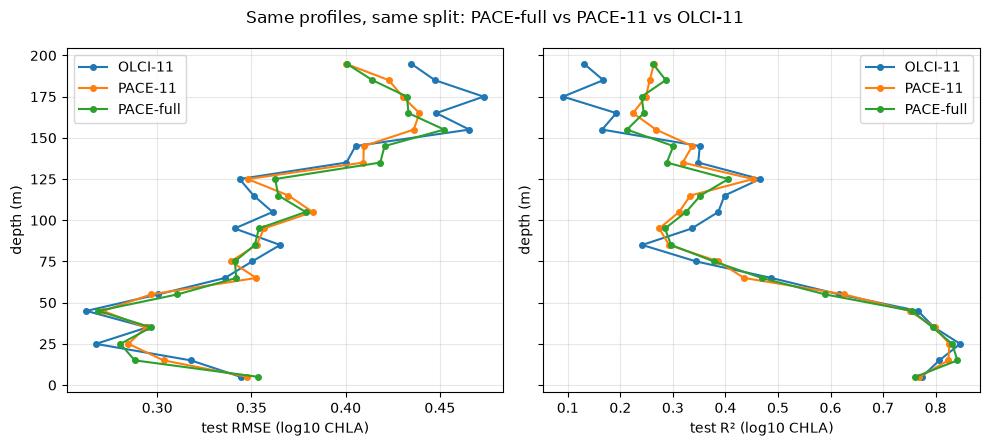

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for name, sub in metrics.groupby("model"):
    sub = sub.sort_values("z")
    axes[0].plot(sub["rmse"], sub["z"], marker="o", ms=4, label=name)
    axes[1].plot(sub["r2"], sub["z"], marker="o", ms=4, label=name)
axes[0].set_xlabel("test RMSE (log10 CHLA)")
axes[1].set_xlabel("test R² (log10 CHLA)")
axes[0].set_ylim(200, 0)  # surface at top; sharey copies this to both
for ax in axes:
    ax.set_ylabel("depth (m)")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("Same profiles, same split: PACE-full vs PACE-11 vs OLCI-11")
fig.tight_layout()

wide = metrics.pivot(index="z", columns="model", values=["rmse", "r2", "n_test"])
wide